In [2]:
# ======================== DATA UNDERSTANDING ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

df = pd.read_csv("../data/ga4_user_daily_funnel.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate user-date:", df.duplicated(subset=['event_date', 'user_pseudo_id']).sum())

(115711, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115711 entries, 0 to 115710
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   event_date      115711 non-null  int64  
 1   user_pseudo_id  115711 non-null  float64
 2   device_type     115711 non-null  object 
 3   traffic_source  115711 non-null  object 
 4   page_views      115711 non-null  int64  
 5   product_views   115711 non-null  int64  
 6   carts           115711 non-null  int64  
 7   checkouts       115711 non-null  int64  
 8   purchases       115711 non-null  int64  
 9   purchased_flag  115711 non-null  int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 8.8+ MB
None
event_date        0
user_pseudo_id    0
device_type       0
traffic_source    0
page_views        0
product_views     0
carts             0
checkouts         0
purchases         0
purchased_flag    0
dtype: int64
Duplicate rows: 0
Duplicate user-date: 9146


**Data Understanding**

Dataset terdiri dari **115,711 baris dan 10 kolom** tanpa missing values.

Beberapa temuan penting:
- Tidak terdapat duplicate rows
- Namun terdapat **9,146 duplicate user-date**, yang berarti satu user bisa memiliki multiple aktivitas dalam satu hari

Insight:
Data perlu di-*aggregate* ke level user per hari agar funnel analysis tidak bias.

In [3]:
# ===================== DATA CLEANING =====================

# Convert date
df['event_date'] = pd.to_datetime(df['event_date'], format='%Y%m%d')

# df_user khusus untuk funnel overall saja
df_user = df.groupby(['event_date', 'user_pseudo_id'], as_index=False).agg({
    'page_views': 'sum',
    'product_views': 'sum',
    'carts': 'sum',
    'checkouts': 'sum',
    'purchases': 'sum',
    'purchased_flag': 'max'
})

df_user = df_user[
    (df_user['checkouts'] <= df_user['carts']) &
    (df_user['purchases'] <= df_user['checkouts'])
]

# Remove inactive users
df_user = df_user[
    df_user[['page_views', 'product_views', 'carts', 'checkouts', 'purchases']].sum(axis=1) > 0
]

print(df_user.shape)

(102951, 8)


**Data Cleaning**

Langkah yang dilakukan:
- Konversi kolom tanggal ke format datetime
- Aggregasi data ke level **user per hari**
- Validasi urutan funnel (checkout ≤ cart, purchase ≤ checkout)
- Menghapus user yang tidak memiliki aktivitas

Hasil:
- Data berkurang menjadi **102,951 user aktif**

Insight:
Sekitar ~11% data merupakan noise / aktivitas tidak valid atau tidak relevan untuk funnel.

In [4]:
# ==================== FEATURE ENGINEERING ==========================

df_user['stage_page_view']    = (df_user['page_views'] > 0).astype(int)
df_user['stage_product_view'] = (df_user['product_views'] > 0).astype(int)
df_user['stage_cart']         = (df_user['carts'] > 0).astype(int)
df_user['stage_checkout']     = (df_user['checkouts'] > 0).astype(int)
df_user['stage_purchase']     = (df_user['purchases'] > 0).astype(int)

In [5]:
# ======================== FUNNEL ANALYSIS ========================

stage_counts = {
    'Page View':    df_user['stage_page_view'].sum(),
    'Product View': df_user['stage_product_view'].sum(),
    'Cart':         df_user['stage_cart'].sum(),
    'Checkout':     df_user['stage_checkout'].sum(),
    'Purchase':     df_user['stage_purchase'].sum()
}

funnel_df = pd.DataFrame({
    'Stage': list(stage_counts.keys()),
    'Users': list(stage_counts.values())
})

funnel_df['Conversion Rate (%)'] = (
    funnel_df['Users'] / funnel_df['Users'].shift(1) * 100
)
funnel_df.loc[0, 'Conversion Rate (%)'] = 100

funnel_df['Drop-off Rate (%)'] = 100 - funnel_df['Conversion Rate (%)']
funnel_df.loc[0, 'Drop-off Rate (%)'] = 0

overall_conversion = (
    funnel_df.loc[funnel_df['Stage'] == 'Purchase', 'Users'].values[0] /
    funnel_df.loc[funnel_df['Stage'] == 'Page View', 'Users'].values[0]
) * 100

print(funnel_df)
print(f"\nOverall Conversion Rate: {overall_conversion:.2f}%")

          Stage   Users  Conversion Rate (%)  Drop-off Rate (%)
0     Page View  102926           100.000000           0.000000
1  Product View   20501            19.918194          80.081806
2          Cart    3397            16.569923          83.430077
3      Checkout     604            17.780394          82.219606
4      Purchase     393            65.066225          34.933775

Overall Conversion Rate: 0.38%


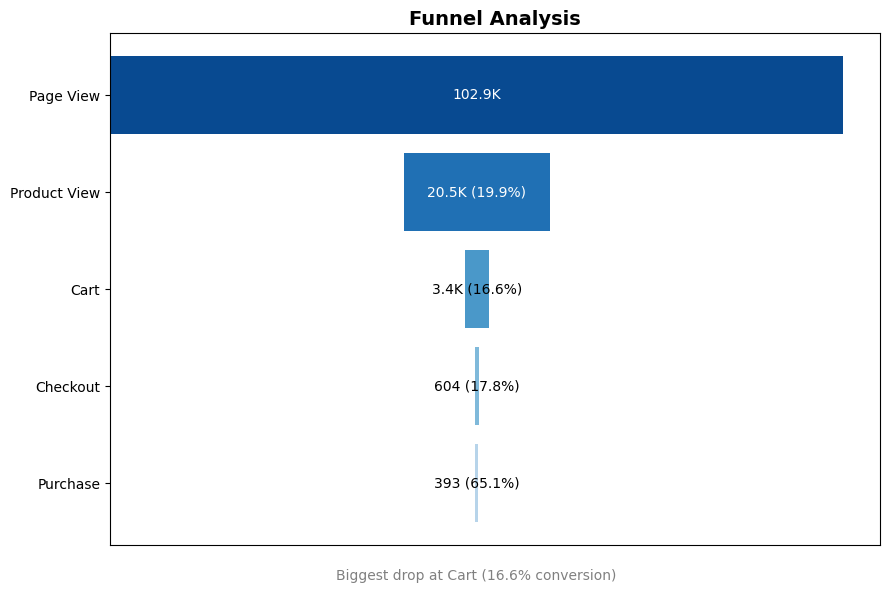

In [6]:
# ======================== VISUALIZATION ========================

stages          = funnel_df['Stage'].values
values          = funnel_df['Users'].values
conversion_rates = funnel_df['Conversion Rate (%)'].values

def format_number(x):
    return f"{x/1000:.1f}K" if x >= 1000 else str(int(x))

max_value = max(values)
norm      = values / max_value
drop_idx  = np.argmin(conversion_rates[1:]) + 1

cmap   = matplotlib.colormaps['Blues']
colors = [cmap(0.9 - i * 0.15) for i in range(len(stages))]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i in range(len(stages)):
    ax.barh(
        y=i,
        width=norm[i],
        left=(1 - norm[i]) / 2,
        color=colors[i]
    )

ax.set_yticks(range(len(stages)))
ax.set_yticklabels(stages)
ax.set_xticks([])
ax.set_title('Funnel Analysis', fontsize=14, fontweight='bold')

for i in range(len(values)):
    user_text = format_number(values[i])
    label     = f"{user_text}" if i == 0 else f"{user_text} ({conversion_rates[i]:.1f}%)"
    ax.text(
        0.5, i, label,
        ha='center', va='center',
        fontsize=10,
        color='white' if norm[i] > 0.15 else 'black'
    )

ax.text(
    0.5, len(stages),
    f"Biggest drop at {stages[drop_idx]} ({conversion_rates[drop_idx]:.1f}% conversion)",
    ha='center', fontsize=10, color='gray'
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/funnel_analysis.png", dpi=300)
plt.show()
plt.close()


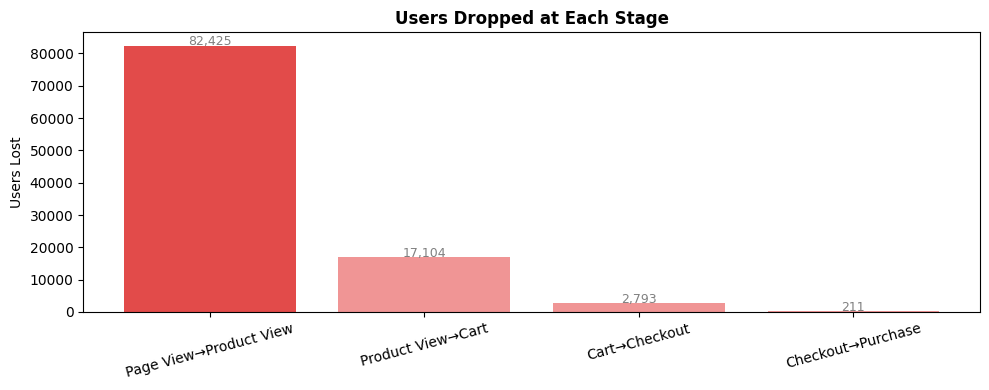

In [7]:
# ======================== DROP-OFF WATERFALL ========================

stages_list = funnel_df['Stage'].tolist()
users_list  = funnel_df['Users'].tolist()

dropoffs = [users_list[i] - users_list[i+1] for i in range(len(users_list)-1)]
dropoff_labels = [f"{stages_list[i]}→{stages_list[i+1]}" for i in range(len(stages_list)-1)]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#E24B4A' if d == max(dropoffs) else '#F09595' for d in dropoffs]
bars = ax.bar(dropoff_labels, dropoffs, color=colors)
ax.set_title('Users Dropped at Each Stage', fontweight='bold')
ax.set_ylabel('Users Lost')
for bar, val in zip(bars, dropoffs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f}', ha='center', fontsize=9, color='gray')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../images/user_dropoffs.png", dpi=300)
plt.show()
plt.close()

In [8]:
# Satu DataFrame untuk semua segmentasi
df_session = df.groupby(
    ['event_date', 'user_pseudo_id', 'device_type', 'traffic_source'],
    as_index=False
).agg({
    'page_views': 'sum',
    'product_views': 'sum',
    'carts': 'sum',
    'checkouts': 'sum',
    'purchases': 'sum',
    'purchased_flag': 'max'
})

In [9]:
# Feature engineering
for col, src in [
    ('stage_page_view', 'page_views'),
    ('stage_product_view', 'product_views'),
    ('stage_cart', 'carts'),
    ('stage_checkout', 'checkouts'),
    ('stage_purchase', 'purchases')
]:
    df_session[col] = (df_session[src] > 0).astype(int)

In [10]:
# Segmentasi device
device_funnel = df_session.groupby('device_type').agg({
    'stage_page_view': 'sum',
    'stage_product_view': 'sum',
    'stage_cart': 'sum',
    'stage_checkout': 'sum',
    'stage_purchase': 'sum'
}).reset_index()

device_funnel['overall_conversion'] = (
    device_funnel['stage_purchase'] / device_funnel['stage_page_view']
)

print(device_funnel)

  device_type  stage_page_view  stage_product_view  stage_cart  \
0     desktop            63625               13311        2618   
1      mobile            43632                9019        1779   
2      tablet             2441                 554          98   

   stage_checkout  stage_purchase  overall_conversion  
0            1230             618            0.009713  
1             860             469            0.010749  
2              52              29            0.011880  


In [11]:
# Segmentasi traffic
traffic_funnel = df_session.groupby('traffic_source').agg({
    'stage_page_view': 'sum',
    'stage_product_view': 'sum',
    'stage_cart': 'sum',
    'stage_checkout': 'sum',
    'stage_purchase': 'sum'
}).reset_index()

traffic_funnel['overall_conversion'] = (
    traffic_funnel['stage_purchase'] / traffic_funnel['stage_page_view']
)

print(traffic_funnel.sort_values('overall_conversion', ascending=False))

                    traffic_source  stage_page_view  stage_product_view  \
0                   (data deleted)             4644                1501   
4  shop.googlemerchandisestore.com             7731                1905   
1                         (direct)            25685                5227   
2                          <Other>            31012                6155   
3                           google            40626                8096   

   stage_cart  stage_checkout  stage_purchase  overall_conversion  
0         421             258             148            0.031869  
4         446             231             130            0.016815  
1        1040             487             256            0.009967  
2        1170             507             253            0.008158  
3        1418             659             329            0.008098  


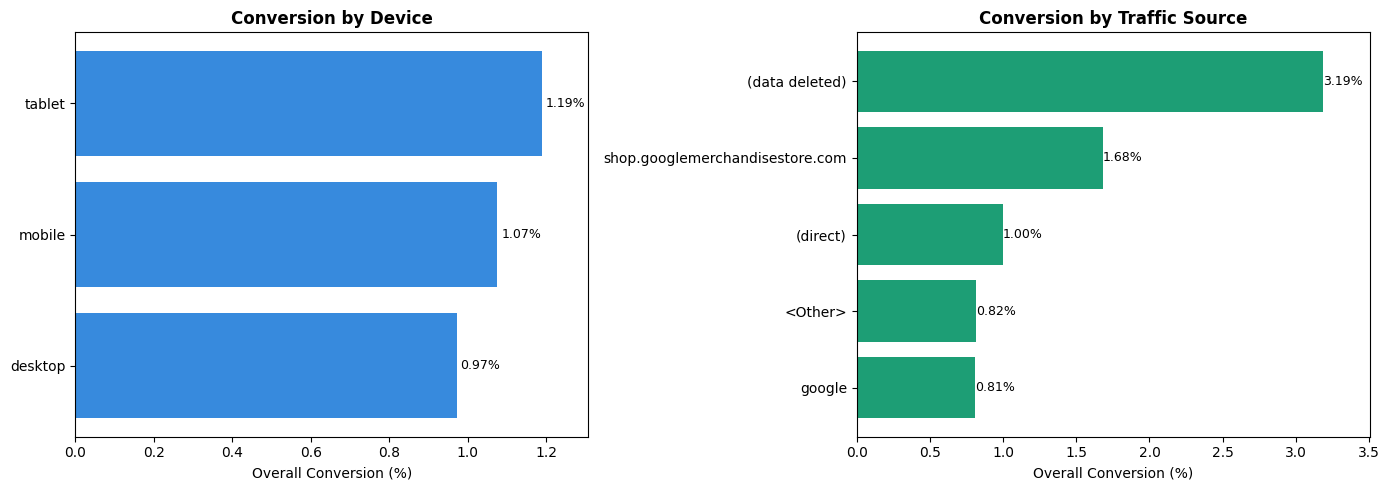

In [12]:
# ======================== SEGMENT COMPARISON CHART ========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device
device_sorted = device_funnel.sort_values('overall_conversion', ascending=True)
axes[0].barh(device_sorted['device_type'], device_sorted['overall_conversion'] * 100,
             color='#378ADD')
axes[0].set_title('Conversion by Device', fontweight='bold')
axes[0].set_xlabel('Overall Conversion (%)')
for i, v in enumerate(device_sorted['overall_conversion'] * 100):
    axes[0].text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)
max_val_device = device_sorted['overall_conversion'].max() * 100
axes[0].set_xlim(0, max_val_device * 1.1)

# Traffic
traffic_top = traffic_funnel.sort_values('overall_conversion', ascending=True)
axes[1].barh(traffic_top['traffic_source'], traffic_top['overall_conversion'] * 100,
             color='#1D9E75')
axes[1].set_title('Conversion by Traffic Source', fontweight='bold')
axes[1].set_xlabel('Overall Conversion (%)')
for i, v in enumerate(traffic_top['overall_conversion'] * 100):
    axes[1].text(v + 0.001, i, f'{v:.2f}%', va='center', fontsize=9)
max_val_traffic = traffic_top['overall_conversion'].max() * 100
axes[1].set_xlim(0, max_val_traffic * 1.1)

plt.tight_layout()
plt.savefig("../images/segment_comparison.png", dpi=300)
plt.show()
plt.close()